# parte 2: Recompensa acumulada em um exemplo poisson

Este notebook organiza a simulação da parte 2 do trabalho. o objetivo é comparar políticas de alocação em termos de recompensa acumulada, exploração e qualidade das estimativas finais das taxas `lambda_a`.

as políticas são implementadas em arquivos `.py` dentro de `src/`. Esse notebook fica responsável apenas por configurar o experimento, executar as simulações, gerar tabelas e produzir visualizações para o relatório.

## Modelo e escolhas de prior

Vamos usar o modelo

$$
R_t \mid a_t = a \sim \text{Poisson}(\lambda_a),
$$

com

$$
\lambda = (18, 20, 21, 23, 27).
$$

Para cada campanha, usamos uma prior independente

$$
\lambda_a \sim \text{Gamma}(\alpha_0, \beta_0),
$$

com parametrização por taxa. A escolha padrão será $\alpha_0 = 4$ e $\beta_0 = 0.2$. Assim,

$$
\mathbb{E}[\lambda_a]
=
\frac{\alpha_0}{\beta_0}
=
\frac{4}{0.2}
=
20,
$$

e

$$
\operatorname{sd}(\lambda_a)
=
\frac{\sqrt{\alpha_0}}{\beta_0}
=
\frac{\sqrt{4}}{0.2}
=
10.
$$

Essa prior tem média na escala esperada do problema, mas ainda permite bastante incerteza antes de observar os dados. Em outras palavras, ela expressa uma crença inicial de que as taxas de novos cadastros estão aproximadamente na ordem de 20 por dia, mas sem forçar que todas as campanhas tenham desempenho muito parecido.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd

# localizar raiz do projeto
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()

# adicionar src ao caminho quando o pacote ainda não estiver instalado
sys.path.append(str(PROJECT_ROOT / "src"))

# definir pastas de saída
DATA_DIR = PROJECT_ROOT / "data" / "processed"
FIGURE_DIR = PROJECT_ROOT / "reports" / "figures"
TABLE_DIR = PROJECT_ROOT / "reports" / "tables"

# criar pastas quando necessário
DATA_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)
TABLE_DIR.mkdir(parents=True, exist_ok=True)

In [2]:
from bandit_inference.analysis_poisson import summarize_poisson_by_policy
from bandit_inference.simulation_poisson import (
    PoissonExperimentConfig,
    run_many_poisson_experiments,
)
from bandit_inference.visualization import save_figure, set_plot_theme
from bandit_inference.visualization_poisson import (
    plot_poisson_allocation_distribution,
    plot_poisson_cumulative_reward,
    plot_poisson_lambda_estimates,
    plot_poisson_optimal_arm_proportion,
    plot_poisson_total_reward_boxplot,
)

# configurar pastas de saída
DATA_DIR = Path("../data/processed")
FIGURE_DIR = Path("../reports/figures")
TABLE_DIR = Path("../reports/tables")

# criar pastas quando ainda não existirem
DATA_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)
TABLE_DIR.mkdir(parents=True, exist_ok=True)

# configurar tema dos gráficos
set_plot_theme()

c:\Users\joaop\OneDrive\Documents\UFSCar\10º SEMESTRE\LEA\bandits-lea\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Configurar experimento

In [3]:
# definir configuração principal do experimento
config = PoissonExperimentConfig(
    horizon=365,
    n_replications=1000,
    seed=6,
    prior_alpha=4.0,
    prior_beta=0.2,
    ucb_exploration=2.0,
    epsilon=0.1,
    trajectory_stride=1,
)

config

PoissonExperimentConfig(n_arms=5, horizon=365, n_replications=1000, lambdas=array([18., 20., 21., 23., 27.]), seed=6, prior_alpha=4.0, prior_beta=0.2, ucb_exploration=2.0, epsilon=0.1, trajectory_stride=1)

## Executar simulações

esta célula gera dois objetos:

- `results`: uma linha por política e replicação, contendo recompensa final, proporções de alocação e erro de estimação das taxas;
- `trajectories`: evolução temporal da recompensa acumulada, usada para gráficos de curva.

In [4]:
# executar muitas replicações para todas as políticas
results, trajectories = run_many_poisson_experiments(
    config=config,
    progress=True,
    save_trajectories=True,
)

# visualizar primeiras linhas dos resultados finais
results.head()

simular replicações poisson:   0%|          | 0/1000 [00:00<?, ?it/s]

simular replicações poisson: 100%|██████████| 1000/1000 [02:08<00:00,  7.81it/s]


,replication,policy,total_reward,average_reward,optimal_arm,optimal_lambda,optimal_arm_pulls,optimal_arm_proportion,lambda_rmse,lambda_mae,...,n_arm_4,prop_arm_4,lambda_hat_arm_4,lambda_error_arm_4,lambda_abs_error_arm_4,n_arm_5,prop_arm_5,lambda_hat_arm_5,lambda_error_arm_5,lambda_abs_error_arm_5
0,0,aleatória uniforme,7916.0,21.687671,5,27.0,72,0.197260,0.609112,0.544296,...,79,0.216438,23.329114,0.329114,0.329114,72,0.197260,26.541667,-0.458333,0.458333
1,0,greedy,9847.0,26.978082,5,27.0,361,0.989041,4.837572,3.820499,...,1,0.002740,15.000000,-8.000000,8.000000,361,0.989041,27.102493,0.102493,0.102493
2,0,thompson sampling,9642.0,26.416438,5,27.0,347,0.950685,4.977995,2.725242,...,11,0.030137,22.909091,-0.090909,0.090909,347,0.950685,26.714697,-0.285303,0.285303
3,0,ucb,9607.0,26.320548,5,27.0,331,0.906849,1.008702,0.844740,...,13,0.035616,21.923077,-1.076923,1.076923,331,0.906849,26.936556,-0.063444,0.063444
4,0,epsilon-greedy,9565.0,26.205479,5,27.0,327,0.895890,1.187850,0.963132,...,6,0.016438,22.333333,-0.666667,0.666667,327,0.895890,26.850153,-0.149847,0.149847


In [5]:
# visualizar primeiras linhas das trajetórias
trajectories.head()

,replication,policy,time,chosen_arm,reward,cumulative_reward,average_reward,optimal_arm_pulls,optimal_arm_proportion
0,0,aleatória uniforme,1,5,25,25.0,25.000000,1,1.000000
1,0,aleatória uniforme,2,1,19,44.0,22.000000,1,0.500000
2,0,aleatória uniforme,3,3,26,70.0,23.333333,1,0.333333
3,0,aleatória uniforme,4,2,17,87.0,21.750000,1,0.250000
4,0,aleatória uniforme,5,4,23,110.0,22.000000,1,0.200000


## Salvar resultados brutos

In [6]:
# salvar resultados em csv
results.to_csv(DATA_DIR / "poisson_results.csv", index=False)
trajectories.to_csv(DATA_DIR / "poisson_trajectories.csv", index=False)

# tentar salvar também em parquet para leitura mais rápida
try:
    results.to_parquet(DATA_DIR / "poisson_results.parquet", index=False)
    trajectories.to_parquet(DATA_DIR / "poisson_trajectories.parquet", index=False)
except ImportError:
    print("pyarrow não encontrado; manter apenas csv")

pyarrow não encontrado; manter apenas csv


## Tabela-resumo por política

In [7]:
# resumir desempenho por política
summary = summarize_poisson_by_policy(results)

# salvar tabela para o relatório
summary.to_csv(TABLE_DIR / "poisson_summary_by_policy.csv", index=False)

summary

,policy,n_replications,total_reward_mean,total_reward_sd,average_reward_mean,optimal_arm_proportion_mean,optimal_arm_proportion_sd,lambda_rmse_mean,lambda_mae_mean,total_reward_se,total_reward_mc_lower,total_reward_mc_upper
0,aleatória uniforme,1000,7959.169,103.587764,21.805942,0.200411,0.021180,0.529194,0.443896,3.275733,7952.748564,7965.589436
1,greedy,1000,9546.974,611.630281,26.156093,0.810115,0.370149,3.220570,2.431852,19.341448,9509.064762,9584.883238
2,thompson sampling,1000,9719.334,112.137760,26.628312,0.934499,0.029706,2.327499,1.690416,3.546107,9712.383630,9726.284370
3,ucb,1000,9630.327,112.992581,26.384458,0.891641,0.028990,1.855101,1.345931,3.573139,9623.323647,9637.330353
4,epsilon-greedy,1000,9579.796,206.783132,26.246016,0.870570,0.114727,1.307293,1.023032,6.539057,9566.979449,9592.612551


## Recompensa acumulada ao longo do tempo

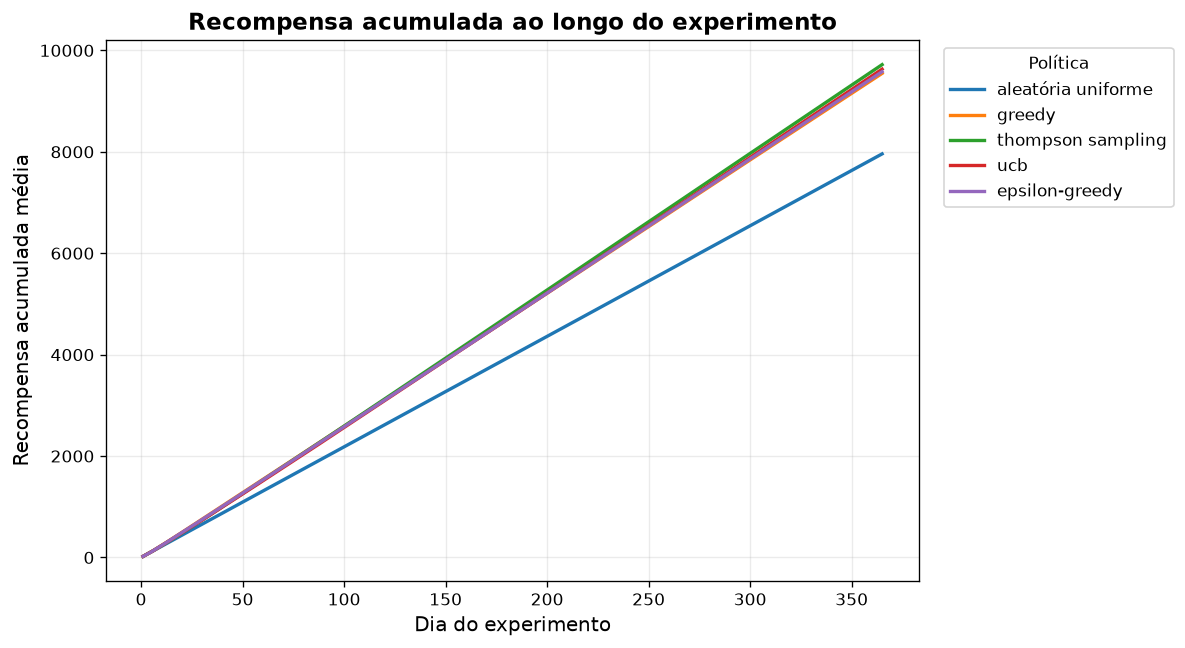

In [8]:
# plotar recompensa acumulada média por política
ax = plot_poisson_cumulative_reward(trajectories)
save_figure(FIGURE_DIR / "poisson_cumulative_reward.png")
plt.show()

## Distribuição da recompensa acumulada final


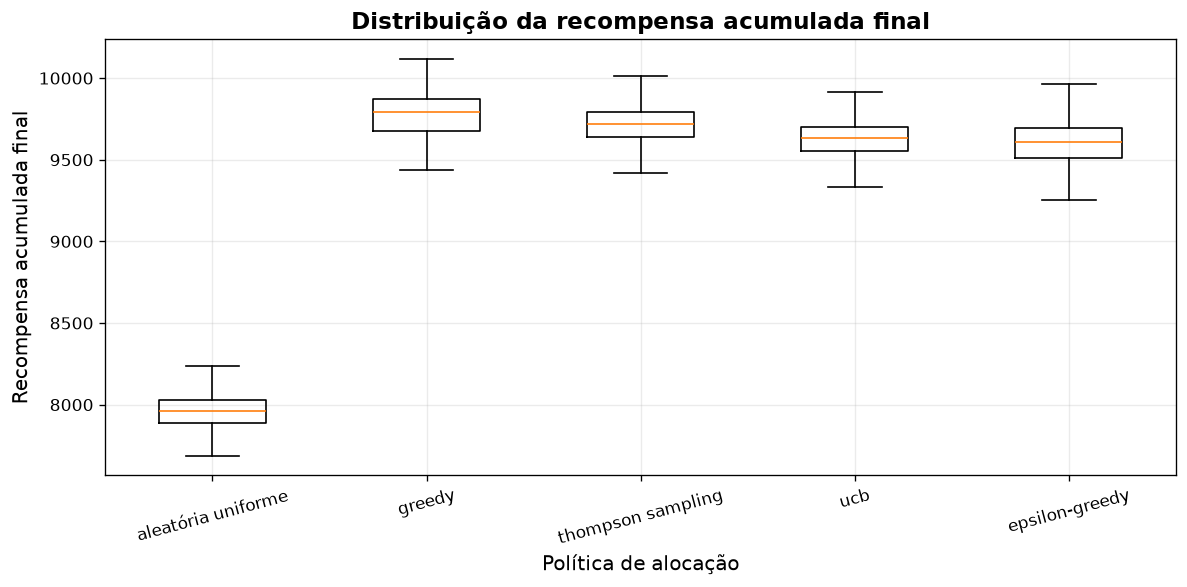

In [9]:
# plotar distribuição da recompensa acumulada final
ax = plot_poisson_total_reward_boxplot(results)
save_figure(FIGURE_DIR / "poisson_total_reward_boxplot.png")
plt.show()

## Exploração da campanha ótima

como a campanha 5 tem a maior taxa verdadeira, a proporção de alocações nela indica o quanto cada política conseguiu explorar a melhor alternativa após aprender com os dados.

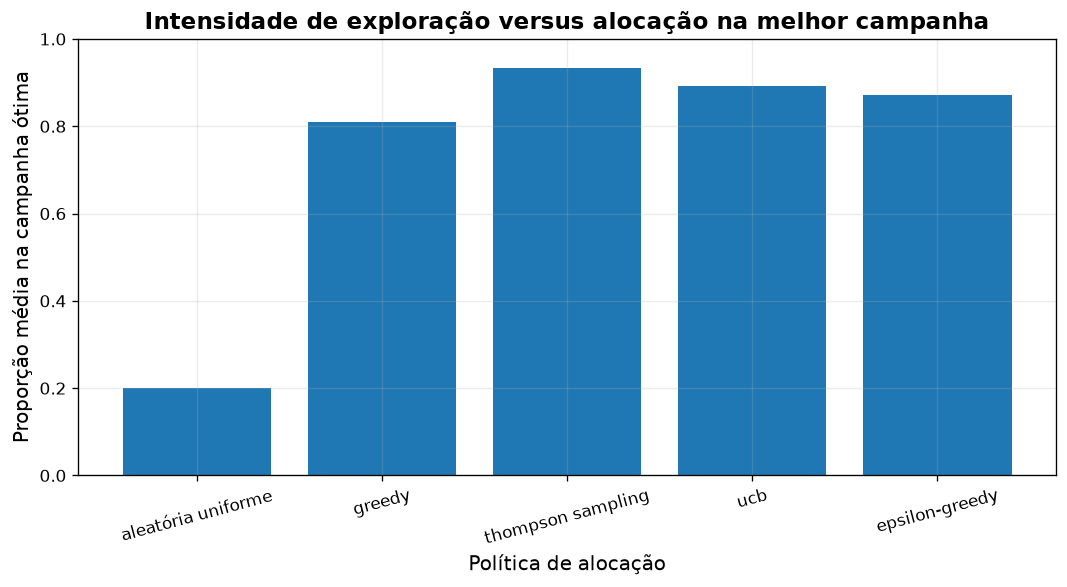

In [10]:
# plotar proporção média de alocação na campanha ótima
ax = plot_poisson_optimal_arm_proportion(results)
save_figure(FIGURE_DIR / "poisson_optimal_arm_proportion.png")
plt.show()

## Distribuição das alocações finais

este gráfico ajuda a responder quais políticas exploram mais. políticas que distribuem mais massa entre várias campanhas exploram mais; políticas que concentram quase tudo na campanha 5 exploram menos e exploram mais a alternativa aparentemente ótima.

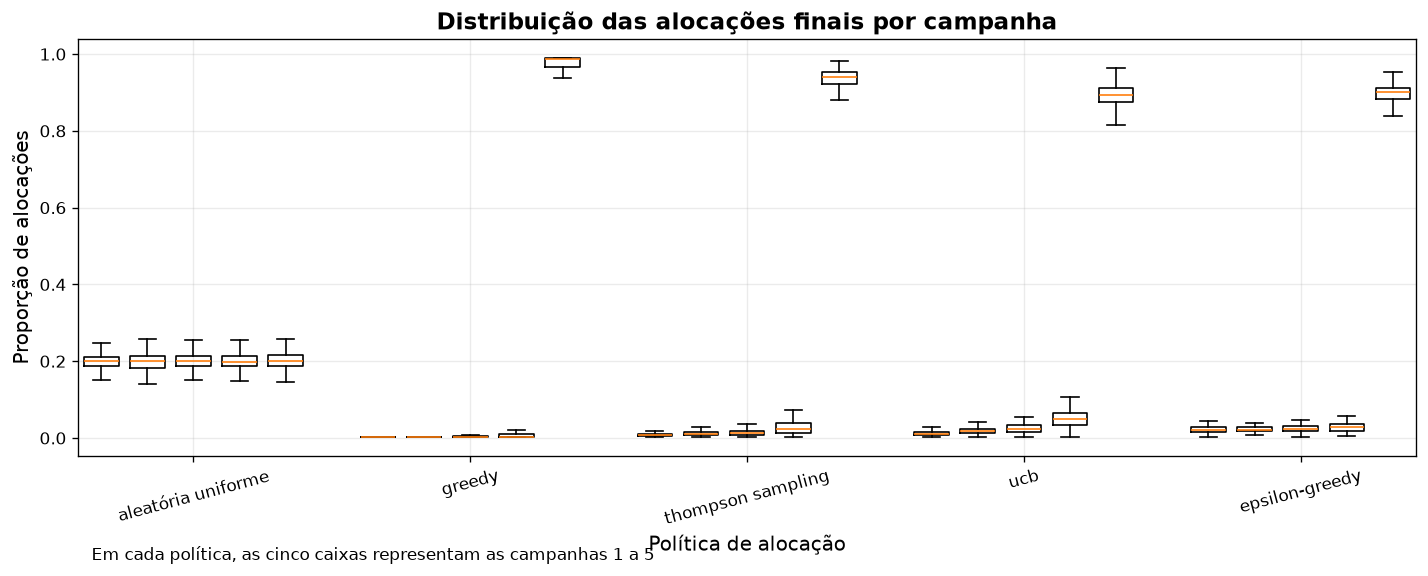

In [11]:
# plotar proporções finais de alocação por campanha
ax = plot_poisson_allocation_distribution(results)
save_figure(FIGURE_DIR / "poisson_allocation_distribution.png")
plt.show()

## Qualidade das estimativas de lambda

Maximizar recompensa acumulada não é necessariamente o mesmo que estimar bem todas as taxas. Políticas muito exploratórias tendem a estimar melhor todos os braços, enquanto políticas mais gananciosas concentram observações nos braços promissores.

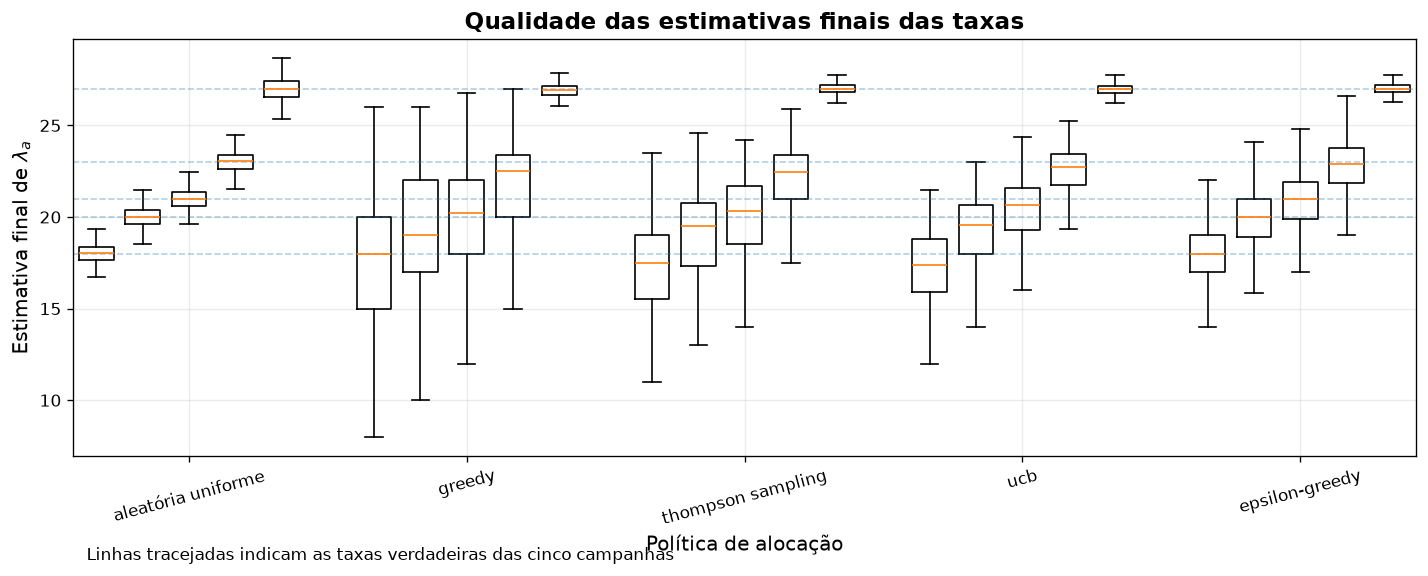

In [12]:
# plotar estimativas finais das taxas por política
ax = plot_poisson_lambda_estimates(results, lambdas=list(config.lambdas))
save_figure(FIGURE_DIR / "poisson_lambda_estimates.png")
plt.show()